In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(dirname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/varun000reddy
/kaggle/input/datasets/varun000reddy/training-50k
/kaggle/input/datasets/varun000reddy/training-50k/deepfashion_50k
/kaggle/input/datasets/varun000reddy/training-50k/deepfashion_50k/annos
/kaggle/input/datasets/varun000reddy/training-50k/deepfashion_50k/images
/kaggle/input/datasets/varun000reddy/training-50k/train_50k
/kaggle/input/datasets/varun000reddy/training-50k/train_50k/annos
/kaggle/input/datasets/varun000reddy/training-50k/train_50k/images
/kaggle/input/datasets/varun000reddy/validation
/kaggle/input/datasets/varun000reddy/validation/validation
/kaggle/input/datasets/varun000reddy/validation/validation/annos
/kaggle/input/datasets/varun000reddy/validation/validation/image
/kaggle/input/datasets/piprewarparag
/kaggle/input/datasets/piprewarparag/unet-checkpoints


In [5]:
!pip install -q segmentation-models-pytorch timm

In [6]:
import torch

checkpoint = torch.load("/kaggle/working/unet_finetune.pth")

print("Last Epoch:", checkpoint["epoch"])

Last Epoch: 6


In [7]:
import os
import json
import random
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF

import segmentation_models_pytorch as smp

torch.backends.cudnn.benchmark = True

In [8]:
BASE_DIR = "/kaggle/input/datasets/varun000reddy/training-50k"  # change this

TRAIN_IMAGE_DIR = f"{BASE_DIR}/train_50k/images"
TRAIN_ANNO_DIR  = f"{BASE_DIR}/train_50k/annos"

VAL_IMAGE_DIR = "/kaggle/input/datasets/varun000reddy/validation/validation/image"
VAL_ANNO_DIR  = "/kaggle/input/datasets/varun000reddy/validation/validation/annos"

TEST_IMAGE_DIR = "/kaggle/input/datasets/varun000reddy/testing/test/test/image"
#TEST_ANNO_DIR  = f"{BASE_DIR}/testing/annos"  - not there

In [9]:
# Optional: verify class frequencies in train annotations
counter = defaultdict(int)

for file in os.listdir(TRAIN_ANNO_DIR):
    if file.endswith(".json"):
        with open(os.path.join(TRAIN_ANNO_DIR, file)) as f:
            data = json.load(f)
        for key in data:
            if key.startswith("item"):
                item = data[key]
                cname = item.get("category_name", None)
                if cname is None:
                    cid = item.get("category_id", None)
                    # fallback mapping from DeepFashion2 ids
                    cid_to_name = {
                        1: "short sleeve top",
                        2: "long sleeve top",
                        3: "short sleeve outwear",
                        4: "long sleeve outwear",
                        5: "vest",
                        6: "sling",
                        7: "shorts",
                        8: "trousers",
                        9: "skirt",
                        10: "short sleeve dress",
                        11: "long sleeve dress",
                        12: "vest dress",
                        13: "sling dress",
                    }
                    cname = cid_to_name.get(cid, None)
                if cname is not None:
                    counter[cname] += 1

print(sorted(counter.items(), key=lambda x: x[1], reverse=True)[:10])

[('short sleeve top', 18670), ('trousers', 14442), ('shorts', 9543), ('long sleeve top', 9388), ('skirt', 8032), ('vest dress', 4667), ('short sleeve dress', 4485), ('vest', 4194), ('long sleeve outwear', 3507), ('long sleeve dress', 2052)]


In [10]:
label_map = {
    "background": 0,
    "short sleeve top": 1,
    "trousers": 2,
    "shorts": 3,
    "long sleeve top": 4,
    "skirt": 5
}

with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("Saved /kaggle/working/label_map.json")

Saved /kaggle/working/label_map.json


Convert annotation polygons to mask

In [11]:
CID_TO_NAME = {
    1: "short sleeve top",
    2: "long sleeve top",
    3: "short sleeve outwear",
    4: "long sleeve outwear",
    5: "vest",
    6: "sling",
    7: "shorts",
    8: "trousers",
    9: "skirt",
    10: "short sleeve dress",
    11: "long sleeve dress",
    12: "vest dress",
    13: "sling dress",
}



In [12]:
import numpy as np
import cv2

def create_mask_from_anno(anno_dict, h, w, label_map):
    mask = np.zeros((h, w), dtype=np.uint8)

    for key in anno_dict:
        if not key.startswith("item"):
            continue

        item = anno_dict[key]

        cid = item.get("category_id", None)
        cname = CID_TO_NAME.get(cid, None)

        # skip if not in your 5 classes
        if cname not in label_map:
            continue

        class_id = label_map[cname]

        for poly in item.get("segmentation", []):
            if poly is None or len(poly) < 6:
                continue

            pts = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts], class_id)

    return mask

In [13]:
# !ls -lh /kaggle/working/

Dataset class

In [14]:
class DeepFashionSegDataset(Dataset):
    def __init__(self, image_dir, anno_dir, label_map, image_size=256, train=True):
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.label_map = label_map
        self.image_size = image_size
        self.train = train

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
            and os.path.exists(os.path.join(anno_dir, os.path.splitext(f)[0] + ".json"))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        anno_path = os.path.join(self.anno_dir, os.path.splitext(img_name)[0] + ".json")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        with open(anno_path, "r") as f:
            anno = json.load(f)

        mask = create_mask_from_anno(anno, img.shape[0], img.shape[1], self.label_map)

        # simple augmentation
        if self.train and random.random() < 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)

        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        img = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        mask = torch.from_numpy(mask).long()  # [H, W], values 0..5
        return img, mask

Dataloaders

In [15]:
IMG_SIZE = 256
BATCH_SIZE = 16  #using smaller batch size for segmentation
NUM_CLASSES = len(label_map)  # 6 = background + 5 classes

train_ds = DeepFashionSegDataset(TRAIN_IMAGE_DIR, TRAIN_ANNO_DIR, label_map, image_size=IMG_SIZE, train=True)
val_ds   = DeepFashionSegDataset(VAL_IMAGE_DIR, VAL_ANNO_DIR, label_map, image_size=IMG_SIZE, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("train:", len(train_ds), "val:", len(val_ds))
x, y = train_ds[0]
print(x.shape, y.shape, y.min().item(), y.max().item())

train: 49980 val: 32153
torch.Size([3, 256, 256]) torch.Size([256, 256]) 0 0


In [16]:
for i in range(20):
    _, mask = train_ds[i]
    print(np.unique(mask.numpy()))

[0]
[0 4]
[0 4]
[0 2 4]
[0 1 5]
[0 3]
[0 1 3]
[0 1 3]
[0 1 3]
[0 1 3]
[0 1 3]
[0 1 3]
[0 1 3]
[0 1 5]
[0 1 5]
[0 1]
[0 1 2]
[0 1 2]
[0 1 2]
[0 1 2]


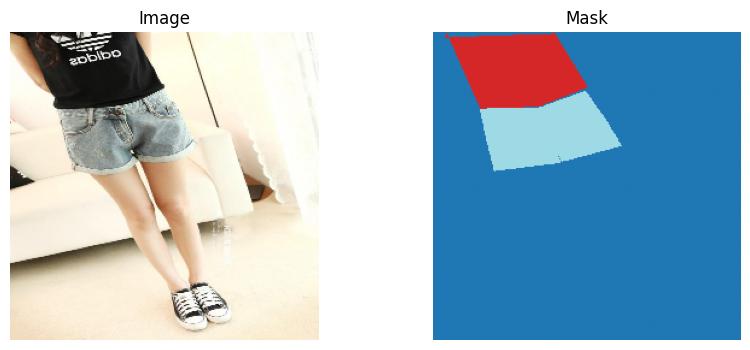

In [17]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean


img, mask = train_ds[6]

img_vis = denormalize(img).permute(1,2,0).numpy()
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_vis)
plt.axis("off")
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.numpy(), cmap="tab20")
plt.axis("off")
plt.title("Mask")

plt.show()

class Weighting to resolve class imbalance problem

In [18]:
import numpy as np

class_counts = np.zeros(NUM_CLASSES)

for i in range(len(train_ds)):
    _, mask = train_ds[i]
    mask_np = mask.numpy()

    for c in range(NUM_CLASSES):
        class_counts[c] += np.sum(mask_np == c)

print(class_counts)

[2.65531979e+09 2.43087248e+08 1.11565345e+08 6.44806010e+07
 1.30868690e+08 7.01676090e+07]


In [19]:
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum()

print(class_weights)

[0.0074054  0.0808916  0.17625291 0.30495554 0.15025532 0.28023923]


# Building Unet  - Training from Scratch


**My model performs semantic segmentation using U-Net.It predicts pixel-wise class labels for clothing items. evaluating it using Dice score and mean IoU.**


In [20]:
#setup , device
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import segmentation_models_pytorch as smp

NUM_CLASSES = 6  # background + 5 classes

def build_model(pretrained=False):
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet" if pretrained else None,
        in_channels=3,
        classes=NUM_CLASSES
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(pretrained=False)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


loss + optimizer

In [21]:
import torch

weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Metrics(Dice + mIoU)

In [22]:
def dice_score(pred, target, num_classes=6):
    pred = torch.argmax(pred, dim=1)

    dice = 0
    count = 0

    for cls in range(1, num_classes):  # skip background
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()

        if union > 0:
            dice += (2 * intersection) / (union + 1e-6)
            count += 1

    return dice / count if count > 0 else torch.tensor(0.0)


def iou_score(pred, target, num_classes=6):
    pred = torch.argmax(pred, dim=1)

    iou = 0
    count = 0

    for cls in range(1, num_classes):  # skip background
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum() - intersection

        if union > 0:
            iou += intersection / (union + 1e-6)
            count += 1

    return iou / count if count > 0 else torch.tensor(0.0)

checkpoint + history

In [23]:
import os

checkpoint_path = "/kaggle/working/unet_scratch.pth"

start_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]
    history = checkpoint["history"]

    print("Resuming from epoch", start_epoch)

Loading checkpoint...
Resuming from epoch 10


In [24]:
!pip install tqdm

Training loop Final

In [25]:
num_epochs = 10

for epoch in range(start_epoch, num_epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    running_dice = 0
    running_iou = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, masks in train_bar:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        d = dice_score(outputs, masks)
        iou = iou_score(outputs, masks)

        running_loss += loss.item()
        running_dice += d.item()
        running_iou += iou.item()

        train_bar.set_postfix({
            "loss": loss.item(),
            "dice": d.item(),
            "miou": iou.item()
        })

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_dice = 0
    val_iou = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for images, masks in val_bar:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            d = dice_score(outputs, masks)
            iou = iou_score(outputs, masks)

            val_loss += loss.item()
            val_dice += d.item()
            val_iou += iou.item()

            val_bar.set_postfix({
                "val_loss": loss.item(),
                "val_dice": d.item(),
                "val_iou": iou.item()
            })

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    # -------- SAVE HISTORY --------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"\nEpoch {epoch+1}/{num_epochs} → "
          f"Train Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, mIoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, mIoU: {val_iou:.4f}")

    # -------- SAVE CHECKPOINT --------
    checkpoint = {
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history
    }

    torch.save(checkpoint, checkpoint_path)

above progress not showed, bcz it resumed from last checkpoint means already trained earlier as we restart session it doesnt show progress history and session is just of 12hr limit and also 30gb ram limit which gets full by mostly 4 epoch so each time restart with checkpoint and moved forward.so down below traversed the history of epoch by saving history of epoch through checkpoint

In [26]:
checkpoint = torch.load("/kaggle/working/unet_scratch.pth")
history = checkpoint["history"]

for i in range(len(history["train_loss"])):
    print(f"Epoch {i+1} | "
          f"Train Loss: {history['train_loss'][i]:.4f} | "
          f"Val Loss: {history['val_loss'][i]:.4f} | "
          f"Train Dice: {history['train_dice'][i]:.4f} | "
          f"Val Dice: {history['val_dice'][i]:.4f} | "
          f"Train mIoU: {history['train_iou'][i]:.4f} | "
          f"Val mIoU: {history['val_iou'][i]:.4f}")

Epoch 1 | Train Loss: 1.0838 | Val Loss: 0.9690 | Train Dice: 0.2787 | Val Dice: 0.1973 | Train mIoU: 0.1871 | Val mIoU: 0.1437
Epoch 2 | Train Loss: 0.9358 | Val Loss: 0.8822 | Train Dice: 0.3541 | Val Dice: 0.2542 | Train mIoU: 0.2411 | Val mIoU: 0.1869
Epoch 3 | Train Loss: 0.8359 | Val Loss: 0.8603 | Train Dice: 0.4014 | Val Dice: 0.2809 | Train mIoU: 0.2758 | Val mIoU: 0.2064
Epoch 4 | Train Loss: 0.7874 | Val Loss: 0.7885 | Train Dice: 0.4206 | Val Dice: 0.2852 | Train mIoU: 0.2924 | Val mIoU: 0.2090
Epoch 5 | Train Loss: 0.7399 | Val Loss: 0.7834 | Train Dice: 0.4372 | Val Dice: 0.2965 | Train mIoU: 0.3072 | Val mIoU: 0.2210
Epoch 6 | Train Loss: 0.7047 | Val Loss: 0.8225 | Train Dice: 0.4492 | Val Dice: 0.2959 | Train mIoU: 0.3183 | Val mIoU: 0.2201
Epoch 7 | Train Loss: 0.6699 | Val Loss: 0.7324 | Train Dice: 0.4617 | Val Dice: 0.3075 | Train mIoU: 0.3291 | Val mIoU: 0.2310
Epoch 8 | Train Loss: 0.6358 | Val Loss: 0.7144 | Train Dice: 0.4747 | Val Dice: 0.3139 | Train mIoU: 0.

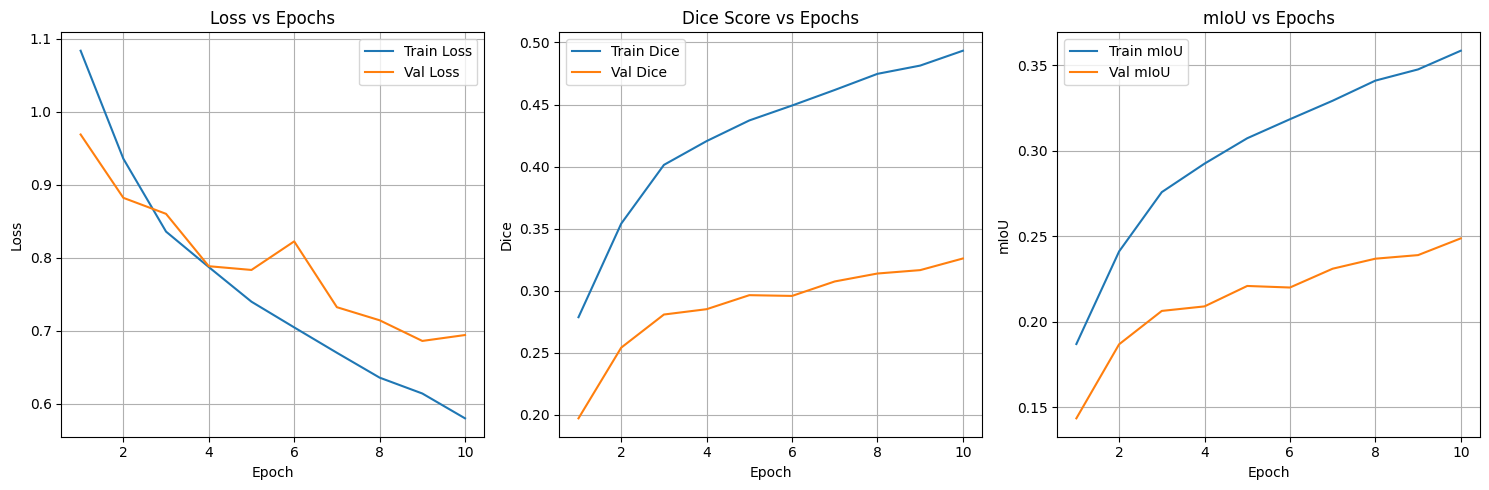

In [27]:
checkpoint = torch.load("/kaggle/working/unet_scratch.pth")
history = checkpoint["history"]

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15,5))

# 🔹 Loss
plt.subplot(1,3,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# 🔹 Dice
plt.subplot(1,3,2)
plt.plot(epochs, history["train_dice"], label="Train Dice")
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.title("Dice Score vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# 🔹 IoU (mAP equivalent for segmentation)
plt.subplot(1,3,3)
plt.plot(epochs, history["train_iou"], label="Train mIoU")
plt.plot(epochs, history["val_iou"], label="Val mIoU")
plt.title("mIoU vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Fine tuning model on transfer learning 

freeze encoder (transfer learning)

In [28]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch

NUM_CLASSES = 6

def build_model(pretrained=False):
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet" if pretrained else None,
        in_channels=3,
        classes=NUM_CLASSES
    )

# 🔹 Build pretrained model
model = build_model(pretrained=True)

# 🔹 Multi-GPU
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


optimizer (only trainable params)

In [29]:
def get_base_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

base_model = get_base_model(model)

for param in base_model.encoder.parameters():
    param.requires_grad = False

In [30]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

load checkpoint(transfer stage)

In [31]:
checkpoint_path = "/kaggle/working/unet_transfer_stage1.pth"

start_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]
    history = checkpoint["history"]

    print("Resuming transfer from epoch", start_epoch)

Resuming transfer from epoch 5


training loop for transfer learning

In [32]:
num_epochs = 5

for epoch in range(start_epoch, num_epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    running_dice = 0
    running_iou = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, masks in train_bar:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        d = dice_score(outputs, masks)
        iou = iou_score(outputs, masks)

        running_loss += loss.item()
        running_dice += d.item()
        running_iou += iou.item()

        train_bar.set_postfix({
            "loss": loss.item(),
            "dice": d.item(),
            "miou": iou.item()
        })

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_dice = 0
    val_iou = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for images, masks in val_bar:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            d = dice_score(outputs, masks)
            iou = iou_score(outputs, masks)

            val_loss += loss.item()
            val_dice += d.item()
            val_iou += iou.item()

            val_bar.set_postfix({
                "val_loss": loss.item(),
                "val_dice": d.item(),
                "val_iou": iou.item()
            })

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    # -------- SAVE HISTORY --------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"\nEpoch {epoch+1}/{num_epochs} → "
          f"Train Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, mIoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, mIoU: {val_iou:.4f}")

    # -------- SAVE CHECKPOINT --------
    checkpoint = {
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history
    }

    torch.save(checkpoint, checkpoint_path)

In [33]:
checkpoint = torch.load("/kaggle/working/unet_transfer_stage1.pth")
history = checkpoint["history"]

for i in range(len(history["train_loss"])):
    print(f"Epoch {i+1} | "
          f"Train Loss: {history['train_loss'][i]:.4f} | "
          f"Val Loss: {history['val_loss'][i]:.4f} | "
          f"Train Dice: {history['train_dice'][i]:.4f} | "
          f"Val Dice: {history['val_dice'][i]:.4f} | "
          f"Train mIoU: {history['train_iou'][i]:.4f} | "
          f"Val mIoU: {history['val_iou'][i]:.4f}")

Epoch 1 | Train Loss: 1.0261 | Val Loss: 0.8216 | Train Dice: 0.3296 | Val Dice: 0.2806 | Train mIoU: 0.2142 | Val mIoU: 0.2037
Epoch 2 | Train Loss: 0.8317 | Val Loss: 0.7532 | Train Dice: 0.4040 | Val Dice: 0.2952 | Train mIoU: 0.2750 | Val mIoU: 0.2173
Epoch 3 | Train Loss: 0.7591 | Val Loss: 0.7156 | Train Dice: 0.4327 | Val Dice: 0.3071 | Train mIoU: 0.3001 | Val mIoU: 0.2296
Epoch 4 | Train Loss: 0.6783 | Val Loss: 0.6839 | Train Dice: 0.4786 | Val Dice: 0.3516 | Train mIoU: 0.3354 | Val mIoU: 0.2593
Epoch 5 | Train Loss: 0.6471 | Val Loss: 0.6521 | Train Dice: 0.4904 | Val Dice: 0.3694 | Train mIoU: 0.3459 | Val mIoU: 0.2768


# Fine tuning on above

In [34]:
#Unfreeze Encoder
for param in base_model.encoder.parameters():
    param.requires_grad = True


#new Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5      # lower LR
)

In [35]:
checkpoint_path = "/kaggle/working/unet_finetune.pth"

start_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]
    history = checkpoint["history"]

    print("Resuming transfer from epoch", start_epoch)

start_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]
    history = checkpoint["history"]

    print("Resuming transfer from epoch", start_epoch)

Resuming transfer from epoch 6
Resuming transfer from epoch 6


Training loop : fine tuning

In [36]:
num_epochs = 10

for epoch in range(start_epoch, num_epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    running_dice = 0
    running_iou = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, masks in train_bar:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        d = dice_score(outputs, masks)
        iou = iou_score(outputs, masks)

        running_loss += loss.item()
        running_dice += d.item()
        running_iou += iou.item()

        train_bar.set_postfix({
            "loss": loss.item(),
            "dice": d.item(),
            "miou": iou.item()
        })

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)
    train_iou = running_iou / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_dice = 0
    val_iou = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for images, masks in val_bar:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            d = dice_score(outputs, masks)
            iou = iou_score(outputs, masks)

            val_loss += loss.item()
            val_dice += d.item()
            val_iou += iou.item()

            val_bar.set_postfix({
                "val_loss": loss.item(),
                "val_dice": d.item(),
                "val_iou": iou.item()
            })

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    # -------- SAVE HISTORY --------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"\nEpoch {epoch+1}/{num_epochs} → "
          f"Train Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, mIoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, mIoU: {val_iou:.4f}")

    # -------- SAVE CHECKPOINT --------
    checkpoint = {
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history
    }

    torch.save(checkpoint, checkpoint_path)

Epoch 7/10 [Val]: 100%|██████████| 2010/2010 [21:28<00:00,  1.56it/s, val_loss=0.348, val_dice=0, val_iou=0]           



Epoch 7/10 → Train Loss: 0.2621, Dice: 0.6326, mIoU: 0.4958 | Val Loss: 0.5473, Dice: 0.3772, mIoU: 0.2998


Epoch 8/10 [Val]: 100%|██████████| 2010/2010 [21:20<00:00,  1.57it/s, val_loss=0.391, val_dice=0, val_iou=0]           



Epoch 8/10 → Train Loss: 0.2334, Dice: 0.6460, mIoU: 0.5106 | Val Loss: 0.5516, Dice: 0.3790, mIoU: 0.3014


Epoch 9/10 [Val]: 100%|██████████| 2010/2010 [21:22<00:00,  1.57it/s, val_loss=0.335, val_dice=0, val_iou=0]           



Epoch 9/10 → Train Loss: 0.2150, Dice: 0.6569, mIoU: 0.5221 | Val Loss: 0.5719, Dice: 0.3810, mIoU: 0.3040


Epoch 10/10 [Val]: 100%|██████████| 2010/2010 [21:32<00:00,  1.56it/s, val_loss=0.314, val_dice=0, val_iou=0]           



Epoch 10/10 → Train Loss: 0.2001, Dice: 0.6677, mIoU: 0.5341 | Val Loss: 0.5908, Dice: 0.3759, mIoU: 0.2985


In [37]:
checkpoint = torch.load("/kaggle/working/unet_finetune.pth")
history = checkpoint["history"]

for i in range(len(history["train_loss"])):
    print(f"Epoch {i+1} | "
          f"Train Loss: {history['train_loss'][i]:.4f} | "
          f"Val Loss: {history['val_loss'][i]:.4f} | "
          f"Train Dice: {history['train_dice'][i]:.4f} | "
          f"Val Dice: {history['val_dice'][i]:.4f} | "
          f"Train mIoU: {history['train_iou'][i]:.4f} | "
          f"Val mIoU: {history['val_iou'][i]:.4f}")

Epoch 1 | Train Loss: 0.5480 | Val Loss: 0.5626 | Train Dice: 0.5323 | Val Dice: 0.3944 | Train mIoU: 0.3852 | Val mIoU: 0.3016
Epoch 2 | Train Loss: 0.4916 | Val Loss: 0.5375 | Train Dice: 0.5368 | Val Dice: 0.3615 | Train mIoU: 0.3983 | Val mIoU: 0.2835
Epoch 3 | Train Loss: 0.4229 | Val Loss: 0.5212 | Train Dice: 0.5642 | Val Dice: 0.3656 | Train mIoU: 0.4249 | Val mIoU: 0.2879
Epoch 4 | Train Loss: 0.3757 | Val Loss: 0.5234 | Train Dice: 0.5824 | Val Dice: 0.3719 | Train mIoU: 0.4434 | Val mIoU: 0.2944
Epoch 5 | Train Loss: 0.3312 | Val Loss: 0.5417 | Train Dice: 0.6001 | Val Dice: 0.3671 | Train mIoU: 0.4620 | Val mIoU: 0.2895
Epoch 6 | Train Loss: 0.2934 | Val Loss: 0.5424 | Train Dice: 0.6168 | Val Dice: 0.3751 | Train mIoU: 0.4791 | Val mIoU: 0.2978
Epoch 7 | Train Loss: 0.2621 | Val Loss: 0.5473 | Train Dice: 0.6326 | Val Dice: 0.3772 | Train mIoU: 0.4958 | Val mIoU: 0.2998
Epoch 8 | Train Loss: 0.2334 | Val Loss: 0.5516 | Train Dice: 0.6460 | Val Dice: 0.3790 | Train mIoU: 0.

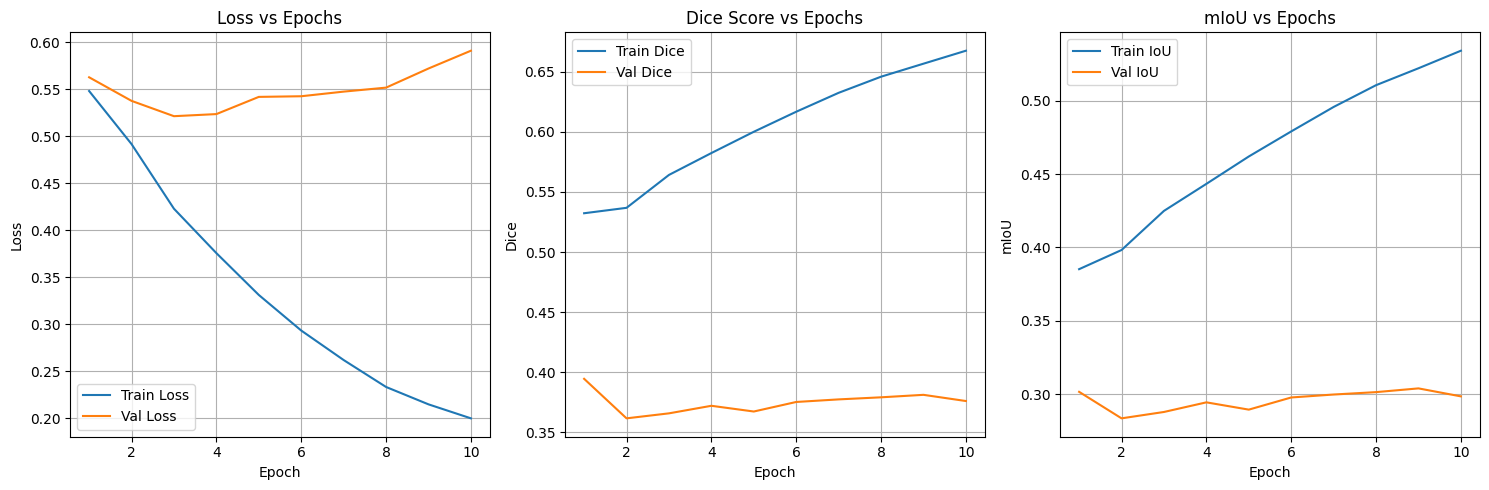

In [38]:
checkpoint = torch.load("/kaggle/working/unet_finetune.pth")
history = checkpoint["history"]

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15,5))

# 🔹 Loss
plt.subplot(1,3,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# 🔹 Dice
plt.subplot(1,3,2)
plt.plot(epochs, history["train_dice"], label="Train Dice")
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.title("Dice Score vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# 🔹 IoU (mAP equivalent for segmentation)
plt.subplot(1,3,3)
plt.plot(epochs, history["train_iou"], label="Train IoU")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.title("mIoU vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()